In [2]:
import subprocess
subprocess.run(['pip', 'install', 'seaborn', 'scikit-learn', 
                'pandas', 'numpy', 'matplotlib', '-q'])
print("✅ Libraries installed!")

✅ Libraries installed!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")
save_path = '/home/azureuser/cloudfiles/code/Users/aazartaheri/'

# Load segmented data
df = pd.read_csv(f'{save_path}bank_segmented.csv')
print(f"✅ Data loaded: {df.shape}")
df.head()

✅ Data loaded: (7842, 19)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,Cluster,Segment
0,33,0,1,2,no,882,no,no,1,21,oct,39,1,151,3,0,no,2,Young Potentials
1,42,0,2,1,no,-247,yes,yes,1,21,oct,519,1,166,1,1,yes,2,Young Potentials
2,33,7,1,1,no,3444,yes,no,1,21,oct,144,1,91,4,0,yes,3,At-Risk Customers
3,36,4,1,2,no,2415,yes,no,1,22,oct,73,1,86,4,1,no,3,At-Risk Customers
4,36,4,1,2,no,0,yes,no,1,23,oct,140,1,143,3,0,yes,3,At-Risk Customers


##  Prepare Data for ML

In [2]:
# Prepare features and target
df_model = df.copy()

# Encode remaining categorical columns
le = LabelEncoder()
cat_cols = ['job', 'marital', 'education', 'contact', 
            'month', 'poutcome', 'housing', 'loan', 'default']

for col in cat_cols:
    if df_model[col].dtype == 'object':
        df_model[col] = le.fit_transform(df_model[col])

# Target variable
df_model['y'] = (df_model['y'] == 'yes').astype(int)

# Features
drop_cols = ['y', 'Segment', 'day']
X = df_model.drop(columns=drop_cols)
y = df_model['y']

print(f"✅ Features: {X.shape}")
print(f"✅ Target distribution:\n{y.value_counts()}")
print(f"\nSubscription rate: {y.mean()*100:.1f}%")

✅ Features: (7842, 16)
✅ Target distribution:
0    6056
1    1786
Name: y, dtype: int64

Subscription rate: 22.8%


##  Split & Scale Data

In [3]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Training set: {X_train.shape}")
print(f"✅ Test set: {X_test.shape}")
print(f"Train subscription rate: {y_train.mean()*100:.1f}%")
print(f"Test subscription rate: {y_test.mean()*100:.1f}%")

✅ Training set: (6273, 16)
✅ Test set: (1569, 16)
Train subscription rate: 22.8%
Test subscription rate: 22.8%


## Train Logistic Regression

In [4]:
# Train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Evaluate
lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_auc = roc_auc_score(y_test, lr_prob)

print("=== Logistic Regression Results ===")
print(f"AUC Score: {lr_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, lr_pred, 
      target_names=['No Subscription', 'Subscription']))

=== Logistic Regression Results ===
AUC Score: 0.8558

Classification Report:
                 precision    recall  f1-score   support

No Subscription       0.87      0.92      0.89      1212
   Subscription       0.66      0.52      0.58       357

       accuracy                           0.83      1569
      macro avg       0.76      0.72      0.74      1569
   weighted avg       0.82      0.83      0.82      1569



## Train Random Forest

In [5]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# Evaluate
rf_pred = rf_model.predict(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]
rf_auc = roc_auc_score(y_test, rf_prob)

print("=== Random Forest Results ===")
print(f"AUC Score: {rf_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred,
      target_names=['No Subscription', 'Subscription']))

=== Random Forest Results ===
AUC Score: 0.9000

Classification Report:
                 precision    recall  f1-score   support

No Subscription       0.88      0.92      0.90      1212
   Subscription       0.69      0.58      0.63       357

       accuracy                           0.85      1569
      macro avg       0.79      0.75      0.77      1569
   weighted avg       0.84      0.85      0.84      1569



## Compare Models Visually

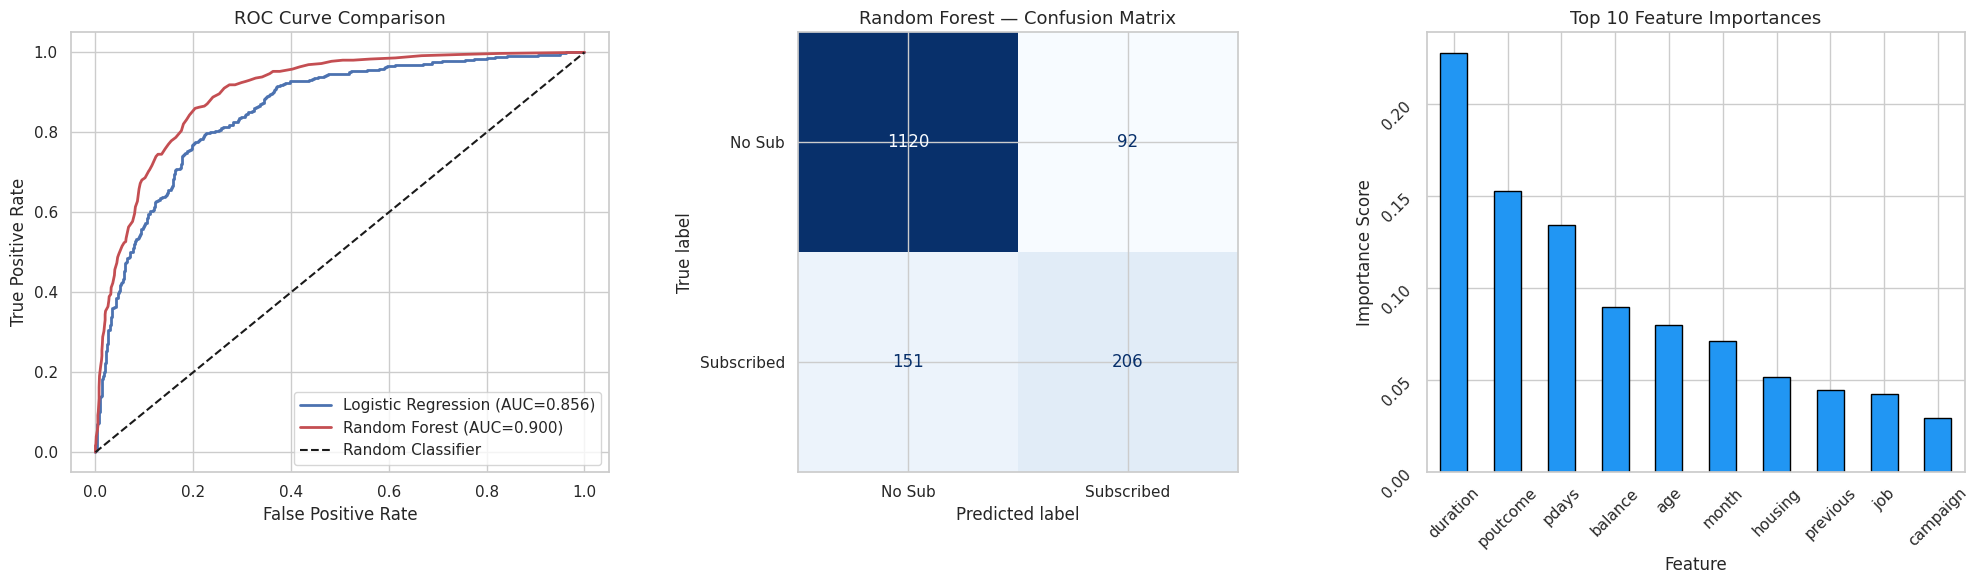

✅ Model comparison chart saved!


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ROC Curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

axes[0].plot(lr_fpr, lr_tpr, 'b-', 
             label=f'Logistic Regression (AUC={lr_auc:.3f})', linewidth=2)
axes[0].plot(rf_fpr, rf_tpr, 'r-', 
             label=f'Random Forest (AUC={rf_auc:.3f})', linewidth=2)
axes[0].plot([0,1], [0,1], 'k--', label='Random Classifier')
axes[0].set_title('ROC Curve Comparison', fontsize=13)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Confusion Matrix - Random Forest
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
       display_labels=['No Sub', 'Subscribed'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Random Forest — Confusion Matrix', fontsize=13)

# Feature Importance
feat_importance = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False).head(10)

feat_importance.plot(kind='bar', ax=axes[2], 
                     color='#2196F3', edgecolor='black')
axes[2].set_title('Top 10 Feature Importances', fontsize=13)
axes[2].set_xlabel('Feature')
axes[2].set_ylabel('Importance Score')
axes[2].tick_params(rotation=45)

plt.tight_layout()
plt.savefig(f'{save_path}model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model comparison chart saved!")

##  Save Model & Results

In [7]:
import pickle
import json

# Save the best model (Random Forest)
with open(f'{save_path}rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open(f'{save_path}scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save results summary
results = {
    'logistic_regression_auc': round(lr_auc, 4),
    'random_forest_auc': round(rf_auc, 4),
    'best_model': 'Random Forest',
    'test_set_size': len(y_test),
    'features_used': list(X.columns)
}

with open(f'{save_path}model_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("✅ Model saved!")
print(f"\n📊 Final Results Summary:")
print(f"   Logistic Regression AUC: {lr_auc:.4f}")
print(f"   Random Forest AUC:       {rf_auc:.4f}")
print(f"   Best Model: Random Forest 🏆")

✅ Model saved!

📊 Final Results Summary:
   Logistic Regression AUC: 0.8558
   Random Forest AUC:       0.9000
   Best Model: Random Forest 🏆
